# Stage 1: Shortcut Candidate Extraction

**Objective:** Engineer 14 gender-associated linguistic features (mix of Hyland hedge lexicon, manual counts, and LIWC-22 categories). Test each as a standalone logistic-regression classifier (5-fold stratified CV, AUC). Features with AUC ≳ 0.60 are flagged as candidate shortcuts. Then use **mutual information (MI) decomposition** to distinguish genuine clinical signal from gender-confounded shortcuts.

| # | Feature | Gender Association | Measurement |
|---|---|---|---|
| 1 | Hedging / epistemic tentativeness | Feminine-coded | Hyland hedge lexicon count / tokens |
| 2 | First-person singular pronouns | Both (depression + feminine) | (I + me + my + myself + mine) / tokens |
| 3 | First-person plural pronouns | Masculine-coded (group identity) | (we + us + our) / tokens |
| 4 | Emotional / feeling language | Feminine-coded | LIWC `Affect` + `feeling` |
| 5 | Relational / social references | Feminine-coded | LIWC `Social`, `family`, `friend` |
| 6 | Certainty / assertive language | Masculine-coded | LIWC `certitude` |
| 7 | Negative emotion words | Both (depression + feminine) | LIWC `emo_neg` |
| 8 | Swear / taboo words | Masculine-coded | LIWC `swear` |
| 9 | Exclamation marks + intensifiers | Feminine-coded | Count of `!`, "so", "really", "very" |
| 10 | Question marks | Feminine-coded | Count of `?` / sentence count |
| 11 | Post length | Feminine-coded (longer posts) | Token count |
| 12 | Apology / self-blame language | Feminine-coded | "sorry", "my fault", "I should have" |
| 13 | Anger expression | Masculine-coded | LIWC `emo_anger` |
| 14 | Body / health references | Both (clinical + gendered) | LIWC `health`, `Physical` |

**Controls** — gender-correlated features whose clinical signal should *survive* conditioning (legitimate gendered signal, not shortcuts):

| # | Control Feature | Rationale | Measurement |
|---|---|---|---|
| C1 | Cognitive processing | Feminine-coded; clinically core (rumination, exec dysfunction) | LIWC `cogproc` |
| C2 | Self-referential rumination | Feminine-coded (self-disclosure × negative affect); central to depression | `fp_singular` × `emo_neg` interaction |
| C3 | Analytical thinking | Gender differences documented; reflects genuine cognitive style | LIWC `Analytic` |
| C4 | Clout / social confidence | Gendered communication style; tracks clinical severity | LIWC `Clout` |

**Data:** 16,306 LIWC-22–annotated posts (all posts by 519 gender-identified users from 47,237 total)

In [43]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

In [44]:
# ── Load LIWC-annotated data ──────────────────────────────────────────────────
df = pd.read_csv('data/strong-ann.csv', low_memory=False)
df['text'] = df['text'].fillna('')

CONDITION = 'autism'
df['binary_label'] = df['TID'].str.split('|').str[1]
df = df[df['binary_label'].isin([CONDITION, 'control'])]
df['binary_label'] = (df['binary_label'] == CONDITION).astype(int)  # 1=adhd, 0=control

min_n = df['binary_label'].value_counts().min()
print(f"Balancing to {min_n} per class")
df = pd.concat([
    df[df['binary_label'] == 0].sample(n=min_n, random_state=42),
    df[df['binary_label'] == 1].sample(n=min_n, random_state=42),
], ignore_index=True)

# Handle gender column name (propagated dataset uses gender_label)
GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'

# Coerce LIWC numeric columns
liwc_cols = ['WC', 'Affect', 'feeling', 'Social', 'family', 'friend',
             'certitude', 'emo_neg', 'swear', 'emo_anger', 'health', 'Physical',
             'cogproc', 'Analytic', 'Clout']
for c in liwc_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"Loaded {len(df):,} rows  (gender column: '{GENDER_COL}')")
print(f"\nLabel distribution:\n{df['binary_label'].value_counts().to_string()}")
print(f"\nGender distribution:\n{df[GENDER_COL].value_counts().to_string()}")
if 'gender_source' in df.columns:
    print(f"\nGender source:\n{df['gender_source'].value_counts().to_string()}")

Balancing to 1534 per class
Loaded 3,068 rows  (gender column: 'gender')

Label distribution:
binary_label
0    1534
1    1534

Gender distribution:
gender
female    1712
male      1356


In [45]:
# ── Hyland (2005) hedge lexicon + text-based helpers ─────────────────────────
# Canonical hedge list from Hyland's academic hedging taxonomy
HYLAND_HEDGES_SINGLE = {
    'about', 'almost', 'apparently', 'approximately', 'argue', 'argued', 'argues',
    'around', 'assume', 'assumed', 'assumes', 'broadly', 'certain', 'claim',
    'claimed', 'claims', 'conceivable', 'conceivably', 'could', 'doubt',
    'doubtful', 'essentially', 'estimate', 'estimated', 'fairly', 'feel',
    'feels', 'felt', 'frequently', 'generally', 'guess', 'hypothesize',
    'hypothesized', 'hypothesizes', 'implication', 'imply', 'indicate',
    'indicated', 'indicates', 'largely', 'likely', 'mainly', 'may', 'maybe',
    'might', 'mostly', 'normally', 'occasionally', 'often', 'partly',
    'perhaps', 'plausible', 'plausibly', 'possible', 'possibly', 'postulate',
    'postulated', 'postulates', 'presumably', 'probable', 'probably', 'quite',
    'rather', 'relatively', 'roughly', 'seem', 'seemed', 'seemingly', 'seems',
    'should', 'sometimes', 'somewhat', 'suggest', 'suggested', 'suggests',
    'suppose', 'supposed', 'supposes', 'suspect', 'suspected', 'suspects',
    'tend', 'tended', 'tends', 'think', 'thinks', 'thought', 'typical',
    'typically', 'uncertain', 'uncertainly', 'unclear', 'unlikely', 'usually',
    'wonder', 'wondered', 'wonders', 'would',
}
HYLAND_HEDGES_MULTI = [
    'kind of', 'sort of', 'more or less', 'to some extent',
    'in general', 'in most cases', 'on the whole', 'for the most part',
    'i think', 'i believe', 'i feel', 'i guess', 'i suppose',
    'it seems', 'it appears', 'in my opinion', 'to my knowledge',
]

FP_SINGULAR = {'i', 'me', 'my', 'myself', 'mine'}
FP_PLURAL   = {'we', 'us', 'our', 'ours', 'ourselves'}

INTENSIFIERS = {'so', 'really', 'very'}

APOLOGY_PHRASES = [
    'sorry', 'i\'m sorry', 'im sorry', 'my fault', 'my bad',
    'i should have', 'i shouldn\'t have', 'i shouldnt have',
    'i apologize', 'i apologise', 'forgive me', 'pardon me',
    'it\'s my fault', 'its my fault', 'i was wrong',
]

def tokenize(text):
    """Simple whitespace + punctuation-aware tokenizer."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

def count_sentences(text):
    """Approximate sentence count via terminal punctuation."""
    sents = re.split(r'[.!?]+', text.strip())
    return max(len([s for s in sents if s.strip()]), 1)

print(f"Hyland single-word hedges: {len(HYLAND_HEDGES_SINGLE)}")
print(f"Hyland multi-word hedges:  {len(HYLAND_HEDGES_MULTI)}")
print(f"Apology phrases:           {len(APOLOGY_PHRASES)}")

Hyland single-word hedges: 98
Hyland multi-word hedges:  17
Apology phrases:           15


In [46]:
# ── Compute all 18 features (14 candidates + 4 controls) ─────────────────────
# We define a master table so every downstream cell can reference it consistently.

FEATURES = {
    # name                    : (gender_assoc,           source)
    'hedge_density'           : ('Feminine-coded',       'text'),
    'fp_singular'             : ('Both (depr + fem)',    'text'),
    'fp_plural'               : ('Masculine-coded',      'text'),
    'emotional_feeling'       : ('Feminine-coded',       'liwc'),
    'social_relational'       : ('Feminine-coded',       'liwc'),
    'certainty'               : ('Masculine-coded',      'liwc'),
    'negative_emotion'        : ('Both (depr + fem)',    'liwc'),
    'swear_words'             : ('Masculine-coded',      'liwc'),
    'excl_intensifiers'       : ('Feminine-coded',       'text'),
    'question_density'        : ('Feminine-coded',       'text'),
    'post_length'             : ('Feminine-coded',       'liwc'),
    'apology_selfblame'       : ('Feminine-coded',       'text'),
    'anger'                   : ('Masculine-coded',      'liwc'),
    'body_health'             : ('Both (clin + gen)',    'liwc'),
    # ── Controls: legitimate gendered clinical signal (should NOT be flagged) ──
    'cogproc'                 : ('Control (fem + clin)', 'liwc'),
    'self_ref_rumination'     : ('Control (fem + clin)', 'derived'),
    'analytic'                : ('Control (gendered)',   'liwc'),
    'clout'                   : ('Control (gendered)',   'liwc'),
}
FEATURE_NAMES = list(FEATURES.keys())

def compute_features(row):
    text = str(row['text'])
    text_lower = text.lower()
    tokens = tokenize(text)
    n_tok = max(len(tokens), 1)
    n_sent = count_sentences(text)

    # 1. Hedging — Hyland lexicon
    hedge_count = sum(1 for t in tokens if t in HYLAND_HEDGES_SINGLE)
    for phrase in HYLAND_HEDGES_MULTI:
        hedge_count += text_lower.count(phrase)
    hedge_density = hedge_count / n_tok

    # 2. First-person singular
    fp_sing = sum(1 for t in tokens if t in FP_SINGULAR) / n_tok

    # 3. First-person plural
    fp_plur = sum(1 for t in tokens if t in FP_PLURAL) / n_tok

    # 4. Emotional / feeling language — LIWC Affect + feeling
    emotional_feeling = np.nanmean([row.get('Affect', 0), row.get('feeling', 0)])

    # 5. Relational / social — LIWC Social, family, friend
    social_relational = np.nanmean([row.get('Social', 0), row.get('family', 0), row.get('friend', 0)])

    # 6. Certainty — LIWC certitude
    certainty = row.get('certitude', 0) or 0

    # 7. Negative emotion — LIWC emo_neg
    negative_emotion = row.get('emo_neg', 0) or 0

    # 8. Swear / taboo — LIWC swear
    swear_words = row.get('swear', 0) or 0

    # 9. Exclamation marks + intensifiers
    excl_count = text.count('!')
    intens_count = sum(1 for t in tokens if t in INTENSIFIERS)
    excl_intensifiers = (excl_count + intens_count) / n_tok

    # 10. Question marks / sentence count
    question_density = text.count('?') / n_sent

    # 11. Post length — LIWC WC
    post_length = row.get('WC', n_tok) or n_tok

    # 12. Apology / self-blame
    apology_count = sum(text_lower.count(p) for p in APOLOGY_PHRASES)
    apology_selfblame = apology_count / n_tok

    # 13. Anger — LIWC emo_anger
    anger = row.get('emo_anger', 0) or 0

    # 14. Body / health — LIWC health + Physical
    body_health = np.nanmean([row.get('health', 0), row.get('Physical', 0)])

    # ── Controls ──────────────────────────────────────────────────────────────
    # C1. Cognitive processing — LIWC cogproc
    cogproc = row.get('cogproc', 0) or 0

    # C2. Self-referential rumination — fp_singular × negative_emotion interaction
    self_ref_rumination = fp_sing * negative_emotion

    # C3. Analytical thinking — LIWC Analytic
    analytic = row.get('Analytic', 0) or 0

    # C4. Clout / social confidence — LIWC Clout
    clout = row.get('Clout', 0) or 0

    return pd.Series({
        'hedge_density': hedge_density,
        'fp_singular': fp_sing,
        'fp_plural': fp_plur,
        'emotional_feeling': emotional_feeling,
        'social_relational': social_relational,
        'certainty': certainty,
        'negative_emotion': negative_emotion,
        'swear_words': swear_words,
        'excl_intensifiers': excl_intensifiers,
        'question_density': question_density,
        'post_length': post_length,
        'apology_selfblame': apology_selfblame,
        'anger': anger,
        'body_health': body_health,
        'cogproc': cogproc,
        'self_ref_rumination': self_ref_rumination,
        'analytic': analytic,
        'clout': clout,
    })

print(f"Computing {len(FEATURE_NAMES)} features (14 candidates + 4 controls) …")
feat_df = df.apply(compute_features, axis=1)
for col in FEATURE_NAMES:
    df[col] = feat_df[col].astype(float)

print("Done.\n")
df[FEATURE_NAMES].describe().round(4)

Computing 18 features (14 candidates + 4 controls) …
Done.



,hedge_density,fp_singular,fp_plural,emotional_feeling,social_relational,certainty,negative_emotion,swear_words,excl_intensifiers,question_density,post_length,apology_selfblame,anger,body_health,cogproc,self_ref_rumination,analytic,clout
count,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3068.0000,3056.0000,3019.0000
mean,0.0262,0.0575,0.0055,2.5426,3.2242,0.6228,0.5804,0.1547,0.0139,0.0970,161.1688,0.0003,0.0940,1.4946,11.7172,0.0402,42.2995,27.9665
std,0.0241,0.0407,0.0121,1.7409,2.3949,1.0586,1.0162,0.6122,0.0189,0.1740,226.9237,0.0025,0.3524,2.2517,5.4941,0.0839,29.1958,28.9479
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
25%,0.0085,0.0235,0.0000,1.3500,1.2833,0.0000,0.0000,0.0000,0.0000,0.0000,52.0000,0.0000,0.0000,0.0000,8.4300,0.0000,16.4100,3.2100
50%,0.0233,0.0580,0.0000,2.3800,2.8317,0.0000,0.0000,0.0000,0.0094,0.0000,99.5000,0.0000,0.0000,0.6600,11.7550,0.0000,37.7000,16.9100
75%,0.0374,0.0860,0.0052,3.5100,4.7867,0.9600,0.8800,0.0000,0.0196,0.1429,196.2500,0.0000,0.0000,1.9662,15.1525,0.0481,65.7425,45.0200
max,0.2308,0.2143,0.1143,15.6250,13.8900,11.4300,10.0000,10.0000,0.2778,2.0000,7687.0000,0.0556,6.2500,22.5000,44.0000,1.1831,99.0000,99.0000


In [50]:
# ================================================================
# MUTUAL INFORMATION DECOMPOSITION — Gender Shortcut Detection
# ================================================================
# For each feature f, compute:
#   I(f; label)         — unconditional MI with mental-health label
#   I(f; gender)        — how strongly the feature correlates with gender
#   I(f; label | gender)— MI with label AFTER conditioning on gender
#
# A feature is a gender shortcut candidate when:
#   • I(f; gender) is high   (feature is gender-correlated)
#   • I(f; label|gender) drops substantially vs I(f; label)
#     (predictive power is partly explained by gender, not clinical content)

from sklearn.feature_selection import mutual_info_classif

# Restrict to male / female for binary MI (largest groups, avoids MI noise)
mi_data = df[df[GENDER_COL].isin(['male', 'female'])].copy()
mi_data['gender_bin'] = (mi_data[GENDER_COL] == 'female').astype(int)

X_feat   = mi_data[FEATURE_NAMES].fillna(0).values.astype(float)
y_label  = mi_data['binary_label'].values.astype(int)
y_gender = mi_data['gender_bin'].values.astype(int)

print(f"MI analysis on {len(mi_data):,} rows  (male: {(y_gender==0).sum():,}, female: {(y_gender==1).sum():,})")

# ── I(f; label) — unconditional ──────────────────────────────────────────────
mi_label = mutual_info_classif(
    X_feat, y_label, discrete_features=False, n_neighbors=5, random_state=42)

# ── I(f; gender) ─────────────────────────────────────────────────────────────
mi_gender = mutual_info_classif(
    X_feat, y_gender, discrete_features=False, n_neighbors=5, random_state=42)

# ── I(f; label | gender) — conditional MI via stratification ─────────────────
#   I(f; label | gender) = Σ_g P(g) · I(f; label)_{within gender=g}
mi_cond = np.zeros(len(FEATURE_NAMES))
for g_val in [0, 1]:
    mask = y_gender == g_val
    p_g  = mask.mean()
    n_g  = mask.sum()
    if n_g >= 30:  # need enough samples for stable MI estimate
        mi_g = mutual_info_classif(
            X_feat[mask], y_label[mask],
            discrete_features=False, n_neighbors=5, random_state=42)
        mi_cond += p_g * mi_g

# ── Build results table ──────────────────────────────────────────────────────
mi_df = pd.DataFrame({
    'feature':            FEATURE_NAMES,
    'gender_assoc':       [FEATURES[f][0] for f in FEATURE_NAMES],
    'I(f;label)':         mi_label,
    'I(f;gender)':        mi_gender,
    'I(f;label|gender)':  mi_cond,
})

# MI drop: how much label-MI is lost after accounting for gender
# Positive = gender confounds (part of signal was gender-mediated)
# Negative = gender suppresses (gender was masking some signal)
mi_df['MI_drop'] = mi_df['I(f;label)'] - mi_df['I(f;label|gender)']

# Percentage drop — only meaningful when I(f;label) is non-negligible
# Use absolute drop in nats as primary metric; % as secondary for I(f;label) > 0.001
MIN_MI = 0.001  # below this, MI estimates are noise-dominated
mi_df['MI_drop_pct'] = np.where(
    mi_df['I(f;label)'] >= MIN_MI,
    (mi_df['MI_drop'] / mi_df['I(f;label)']) * 100,
    np.nan  # undefined when unconditional MI is near zero
)

# Flag: feature is gender-correlated AND conditioning on gender substantially
# reduces its MI with label (>20% drop AND above-median gender correlation)
median_mi_g = mi_df['I(f;gender)'].median()
CONTROL_FEATURES = {'cogproc', 'self_ref_rumination', 'analytic', 'clout'}
mi_df['is_control'] = mi_df['feature'].isin(CONTROL_FEATURES)
mi_df['shortcut_flag'] = (
    ~mi_df['is_control'] &  # controls are excluded from shortcut flagging by design
    (mi_df['I(f;gender)'] > median_mi_g) &
    (mi_df['MI_drop_pct'].fillna(0) > 20)
)

mi_df = mi_df.sort_values('I(f;gender)', ascending=False).reset_index(drop=True)

n_flagged = mi_df['shortcut_flag'].sum()
print(f"\nMedian I(f;gender) = {median_mi_g:.4f}")
print(f"Gender shortcut candidates (I(f;gender) > median AND MI drop > 20%): {n_flagged}\n")

mi_df
pd.set_option('display.float_format', '{:.4f}'.format)
mi_df

MI analysis on 3,068 rows  (male: 1,356, female: 1,712)

Median I(f;gender) = 0.0103
Gender shortcut candidates (I(f;gender) > median AND MI drop > 20%): 4



,feature,gender_assoc,I(f;label),I(f;gender),I(f;label|gender),MI_drop,MI_drop_pct,is_control,shortcut_flag
0,analytic,Control (gendered),0.0349,0.0294,0.0211,0.0137,39.3252,True,False
1,self_ref_rumination,Control (fem + clin),0.0288,0.0259,0.0237,0.0051,17.8126,True,False
2,fp_singular,Both (depr + fem),0.0287,0.0252,0.0149,0.0138,48.0915,False,True
3,certainty,Masculine-coded,0.0084,0.0229,0.0127,-0.0043,-51.3722,False,False
4,excl_intensifiers,Feminine-coded,0.0200,0.0184,0.0209,-0.0008,-4.2129,False,False
5,negative_emotion,Both (depr + fem),0.0192,0.0170,0.0145,0.0047,24.4811,False,True
6,post_length,Feminine-coded,0.0254,0.0144,0.0141,0.0114,44.7050,False,True
7,anger,Masculine-coded,0.0191,0.0137,0.0083,0.0108,56.4169,False,True
8,clout,Control (gendered),0.0111,0.0126,0.0178,-0.0067,-60.5287,True,False
9,body_health,Both (clin + gen),0.0323,0.0080,0.0156,0.0166,51.5600,False,False


In [ ]:
# ================================================================
# MI DECOMPOSITION ON ALL LIWC FEATURES
# ================================================================
# Run the same I(f;Y), I(f;G), I(f;Y|G) decomposition on every
# numeric LIWC column to see the full landscape.

from sklearn.feature_selection import mutual_info_classif

# Identify all numeric LIWC columns (exclude our engineered features and metadata)
meta_cols = {'text', 'TID', 'binary_label', 'gender', 'gender_label', 'gender_source',
             'gender_bin', 'Unnamed: 0', 'author', 'subreddit', 'date', 'id', 'url'}
engineered = set(FEATURE_NAMES)

liwc_all = [c for c in df.columns
            if c not in meta_cols and c not in engineered
            and pd.api.types.is_numeric_dtype(df[c])]

print(f"Found {len(liwc_all)} numeric LIWC columns\n")

# Use the same mi_data (male/female subset)
mi_data2 = df[df[GENDER_COL].isin(['male', 'female'])].copy()
mi_data2['gender_bin'] = (mi_data2[GENDER_COL] == 'female').astype(int)

X_liwc = mi_data2[liwc_all].fillna(0).values.astype(float)
y_lab  = mi_data2['binary_label'].values.astype(int)
y_gen  = mi_data2['gender_bin'].values.astype(int)

# I(f; label) contains BOTH: genuine and spurios signal
mi_l = mutual_info_classif(X_liwc, y_lab, discrete_features=False, n_neighbors=5, random_state=42)

# I(f; gender)
mi_g = mutual_info_classif(X_liwc, y_gen, discrete_features=False, n_neighbors=5, random_state=42)

# I(f; label | gender) via stratification
mi_c = np.zeros(len(liwc_all))
for gv in [0, 1]:
    mask = y_gen == gv
    p = mask.mean()
    if mask.sum() >= 30:
        mi_c += p * mutual_info_classif(
            X_liwc[mask], y_lab[mask],
            discrete_features=False, n_neighbors=5, random_state=42)

# Build table
liwc_mi = pd.DataFrame({
    'feature': liwc_all,
    'I(f;label)': mi_l,
    'I(f;gender)': mi_g,
    'I(f;label|gender)': mi_c,
})
liwc_mi['MI_drop'] = liwc_mi['I(f;label)'] - liwc_mi['I(f;label|gender)']
liwc_mi['MI_drop_pct'] = np.where(
    liwc_mi['I(f;label)'] >= 0.001,
    (liwc_mi['MI_drop'] / liwc_mi['I(f;label)']) * 100, np.nan)

median_g = liwc_mi['I(f;gender)'].median()
liwc_mi['shortcut_flag'] = (
    (liwc_mi['I(f;gender)'] > median_g) &
    (liwc_mi['MI_drop_pct'].fillna(0) > 20)
)

liwc_mi = liwc_mi.sort_values('I(f;gender)', ascending=False).reset_index(drop=True)

n_flag = liwc_mi['shortcut_flag'].sum()
print(f"Median I(f;gender) = {median_g:.4f}")
print(f"Shortcut candidates: {n_flag} / {len(liwc_all)}\n")

pd.set_option('display.max_rows', 120)
liwc_mi

Found 121 numeric LIWC columns

Median I(f;gender) = 0.0064
Shortcut candidates: 32 / 121



,feature,I(f;label),I(f;gender),I(f;label|gender),MI_drop,MI_drop_pct,shortcut_flag
0,feeling,0.0187,0.0571,0.0165,0.0021,11.5057,False
1,age,0.0167,0.0437,0.0130,0.0037,22.3193,True
2,i,0.0285,0.0368,0.0176,0.0108,38.0855,True
3,money,0.0118,0.0367,0.0000,0.0118,100.0000,True
4,ppron,0.0501,0.0287,0.0273,0.0228,45.4895,True
...,...,...,...,...,...,...,...
116,motion,0.0139,0.0000,0.0100,0.0039,27.8189,False
117,filler,0.0000,0.0000,0.0042,-0.0042,NaN,False
118,nonflu,0.0000,0.0000,0.0000,0.0000,NaN,False
119,Exclam,0.0021,0.0000,0.0043,-0.0021,-100.4312,False


In [ ]:
for g_val in [0, 1]:
    mask = y_gender == g_val
    p_g  = mask.mean()       # ← this is p(z)

In [ ]:
mi_cond = 0
for g_val in [0, 1]:              # iterate over z ∈ {male, female}
    mask = y_gender == g_val
    p_g  = mask.mean()            # p(z)
    mi_g = mutual_info_classif(
        X[mask], y[mask], ...)    # I(X; Y | Z=z) — MI within this stratum
    mi_cond += p_g * mi_g         # weighted sum



This is valid because the definition of conditional MI *is* the expectation of within-stratum MI over the conditioning variable. No approximation — it's the definition itself (Cover & Thomas, Theorem 2.5.2).

FLAGGED SHORTCUTS (32 features)
   feature  I(f;label)  I(f;gender)  MI_drop_pct
       age      0.0167       0.0437      22.3193
         i      0.0285       0.0368      38.0855
     money      0.0118       0.0367     100.0000
     ppron      0.0501       0.0287      45.4895
  function      0.0377       0.0286      33.6217
  Analytic      0.0339       0.0285      28.8920
  BigWords      0.0177       0.0265      35.1559
Linguistic      0.0321       0.0225      45.4196
   pronoun      0.0405       0.0214      25.0530
  Physical      0.0192       0.0209      27.5823
   emo_pos      0.0161       0.0200      73.3076
    reward      0.0086       0.0183      83.6223
   discrep      0.0174       0.0179      93.0953
      they      0.0126       0.0168      48.4715
        WC      0.0348       0.0145      43.1955
 Lifestyle      0.0075       0.0129      57.1881
 attention      0.0181       0.0129      54.3621
 prosocial      0.0111       0.0127      45.8584
   emo_neg      0.0424       0.0120  

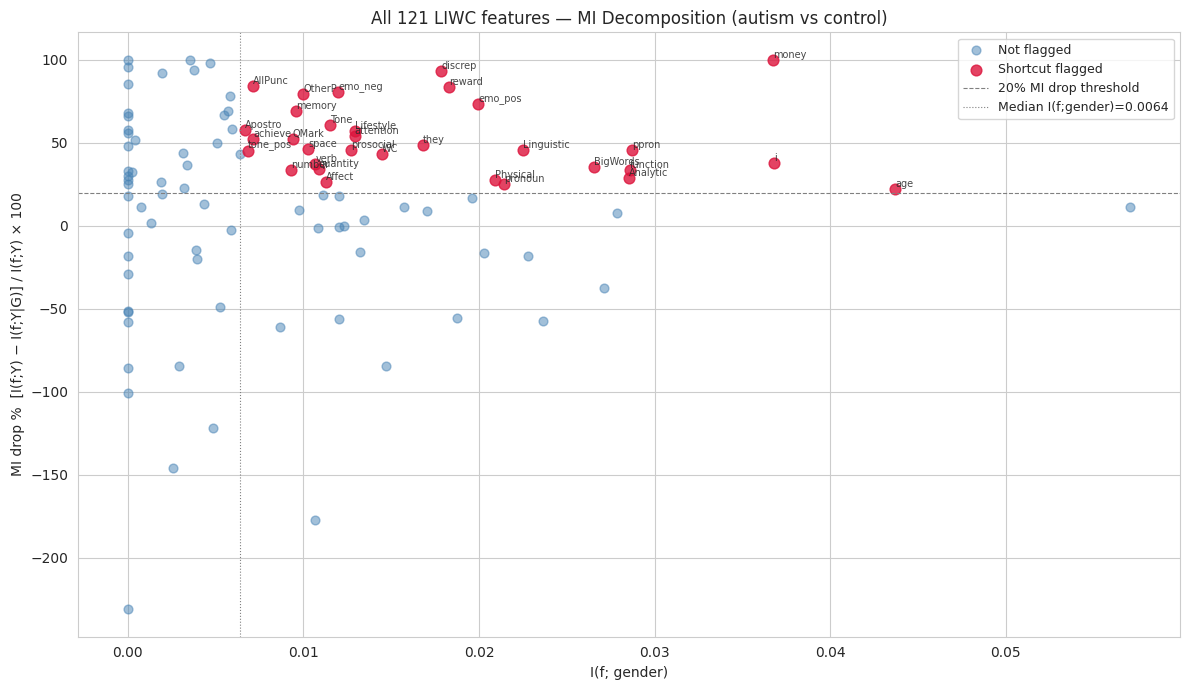

In [52]:
# Show the full flagged shortcuts and top non-flagged
print("=" * 70)
print("FLAGGED SHORTCUTS (32 features)")
print("=" * 70)
print(liwc_mi[liwc_mi['shortcut_flag']][['feature', 'I(f;label)', 'I(f;gender)', 'MI_drop_pct']].to_string(index=False))

print("\n" + "=" * 70)
print("TOP NON-FLAGGED (by I(f;label), gender-correlated but signal survives)")
print("=" * 70)
non_flagged = liwc_mi[~liwc_mi['shortcut_flag']].nlargest(15, 'I(f;label)')
print(non_flagged[['feature', 'I(f;label)', 'I(f;gender)', 'MI_drop_pct']].to_string(index=False))

# ── Scatter plot: I(f;gender) vs MI_drop_pct ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
flagged = liwc_mi[liwc_mi['shortcut_flag']]
safe    = liwc_mi[~liwc_mi['shortcut_flag']]

ax.scatter(safe['I(f;gender)'], safe['MI_drop_pct'], c='steelblue', alpha=0.5, s=40, label='Not flagged')
ax.scatter(flagged['I(f;gender)'], flagged['MI_drop_pct'], c='crimson', alpha=0.8, s=60, label='Shortcut flagged')

# Label the flagged ones
for _, r in flagged.iterrows():
    ax.annotate(r['feature'], (r['I(f;gender)'], r['MI_drop_pct']),
                fontsize=7, alpha=0.85, ha='left', va='bottom')

ax.axhline(20, color='gray', ls='--', lw=0.8, label='20% MI drop threshold')
ax.axvline(median_g, color='gray', ls=':', lw=0.8, label=f'Median I(f;gender)={median_g:.4f}')
ax.set_xlabel('I(f; gender)')
ax.set_ylabel('MI drop %  [I(f;Y) − I(f;Y|G)] / I(f;Y) × 100')
ax.set_title(f'All 121 LIWC features — MI Decomposition ({CONDITION} vs control)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Cross-Condition MI Decomposition + Permutation Test

Run the 18-feature MI decomposition across **all conditions** in the dataset. For each condition, also run a **permutation test** (shuffle gender 200×) to get a data-driven significance threshold for MI drop, replacing the ad-hoc 20%.

In [53]:
# ================================================================
# CROSS-CONDITION MI DECOMPOSITION + PERMUTATION TEST
# ================================================================
from sklearn.feature_selection import mutual_info_classif

# ── Helper: MI decomposition for one condition ────────────────────────────────
def mi_decomposition(df_full, condition, feature_names, gender_col, n_perm=200):
    """
    For a given condition vs control:
      1. Balance classes
      2. Compute I(f;Y), I(f;G), I(f;Y|G) for each feature
      3. Permutation test: shuffle gender n_perm times to get null MI-drop distribution
    Returns a DataFrame with columns per feature + p-values.
    """
    # Filter & balance
    tmp = df_full.copy()
    tmp['_label'] = tmp['TID'].str.split('|').str[1]
    tmp = tmp[tmp['_label'].isin([condition, 'control'])]
    tmp['_y'] = (tmp['_label'] == condition).astype(int)
    min_n = tmp['_y'].value_counts().min()
    if min_n < 50:
        return None  # too few samples
    tmp = pd.concat([
        tmp[tmp['_y'] == 0].sample(n=min_n, random_state=42),
        tmp[tmp['_y'] == 1].sample(n=min_n, random_state=42),
    ], ignore_index=True)

    # Restrict to male/female
    tmp = tmp[tmp[gender_col].isin(['male', 'female'])].copy()
    tmp['_g'] = (tmp[gender_col] == 'female').astype(int)
    if tmp['_g'].nunique() < 2 or len(tmp) < 100:
        return None

    X = tmp[feature_names].fillna(0).values.astype(float)
    y = tmp['_y'].values
    g = tmp['_g'].values

    # Observed MI
    mi_label = mutual_info_classif(X, y, discrete_features=False, n_neighbors=5, random_state=42)
    mi_gender = mutual_info_classif(X, g, discrete_features=False, n_neighbors=5, random_state=42)

    # Conditional MI
    mi_cond = np.zeros(len(feature_names))
    for gv in [0, 1]:
        mask = g == gv
        p = mask.mean()
        if mask.sum() >= 30:
            mi_cond += p * mutual_info_classif(
                X[mask], y[mask], discrete_features=False, n_neighbors=5, random_state=42)

    mi_drop = mi_label - mi_cond

    # ── Permutation test: shuffle gender, recompute MI drop ──────────────────
    rng = np.random.RandomState(42)
    null_drops = np.zeros((n_perm, len(feature_names)))
    for i in range(n_perm):
        g_shuf = rng.permutation(g)
        mi_g_shuf = mutual_info_classif(X, g_shuf, discrete_features=False, n_neighbors=5, random_state=i)
        mi_cond_shuf = np.zeros(len(feature_names))
        for gv in [0, 1]:
            mask = g_shuf == gv
            p = mask.mean()
            if mask.sum() >= 30:
                mi_cond_shuf += p * mutual_info_classif(
                    X[mask], y[mask], discrete_features=False, n_neighbors=5, random_state=i)
        null_drops[i] = mi_label - mi_cond_shuf  # null MI drop under shuffled gender

    # p-value: fraction of null drops >= observed drop
    p_values = np.mean(null_drops >= mi_drop[np.newaxis, :], axis=0)

    # Build result
    res = pd.DataFrame({
        'feature': feature_names,
        'I(f;Y)': mi_label,
        'I(f;G)': mi_gender,
        'I(f;Y|G)': mi_cond,
        'MI_drop': mi_drop,
        'MI_drop_pct': np.where(mi_label >= 0.001, mi_drop / mi_label * 100, np.nan),
        'perm_p': p_values,
        'sig_005': p_values < 0.05,
    })
    res['condition'] = condition
    res['n_samples'] = len(tmp)
    return res

# ── Load full data once ───────────────────────────────────────────────────────
df_full = pd.read_csv('data/strong-ann.csv', low_memory=False)
df_full['text'] = df_full['text'].fillna('')
GENDER_COL_FULL = 'gender_label' if 'gender_label' in df_full.columns else 'gender'

# Coerce LIWC columns
all_liwc = ['WC', 'Affect', 'feeling', 'Social', 'family', 'friend',
            'certitude', 'emo_neg', 'swear', 'emo_anger', 'health', 'Physical',
            'cogproc', 'Analytic', 'Clout']
for c in all_liwc:
    if c in df_full.columns:
        df_full[c] = pd.to_numeric(df_full[c], errors='coerce')

# Compute features on full data
print("Computing features on full dataset …")
feat_full = df_full.apply(compute_features, axis=1)
for col in FEATURE_NAMES:
    df_full[col] = feat_full[col].astype(float)

# Get all conditions
all_conditions = sorted(df_full['TID'].str.split('|').str[1].dropna().unique())
all_conditions = [c for c in all_conditions if c != 'control']
print(f"\nConditions found: {all_conditions}")
print(f"Running MI decomposition + permutation test (200 shuffles) per condition …\n")

# ── Run across all conditions ─────────────────────────────────────────────────
all_results = []
for cond in all_conditions:
    print(f"  {cond} …", end=" ", flush=True)
    res = mi_decomposition(df_full, cond, FEATURE_NAMES, GENDER_COL_FULL, n_perm=200)
    if res is not None:
        n_sig = res['sig_005'].sum()
        print(f"n={res['n_samples'].iloc[0]:,}, shortcuts(p<.05)={n_sig}")
        all_results.append(res)
    else:
        print("skipped (too few samples)")

cross_df = pd.concat(all_results, ignore_index=True)
print(f"\nDone. {len(all_results)} conditions analysed.")

Computing features on full dataset …

Conditions found: ['adhd', 'anxiety', 'autism', 'bipolar', 'depression', 'ocd', 'ptsd']
Running MI decomposition + permutation test (200 shuffles) per condition …

  adhd … n=7,044, shortcuts(p<.05)=6
  anxiety … n=1,394, shortcuts(p<.05)=5
  autism … n=3,068, shortcuts(p<.05)=3
  bipolar … n=3,208, shortcuts(p<.05)=8
  depression … n=2,832, shortcuts(p<.05)=5
  ocd … n=878, shortcuts(p<.05)=5
  ptsd … n=774, shortcuts(p<.05)=2

Done. 7 conditions analysed.


Feature × Condition shortcut matrix (p < 0.05 permutation test)
condition             adhd  anxiety  autism  bipolar  depression    ocd   ptsd  n_conditions  is_control
feature                                                                                                 
fp_singular           True     True    True     True        True   True   True             7       False
analytic              True     True   False     True        True   True   True             6        True
body_health           True     True    True     True        True   True  False             6       False
post_length           True    False    True     True        True  False  False             4       False
self_ref_rumination  False     True   False     True        True  False  False             3        True
hedge_density         True    False   False    False       False   True  False             2       False
negative_emotion     False     True   False     True       False  False  False             2    

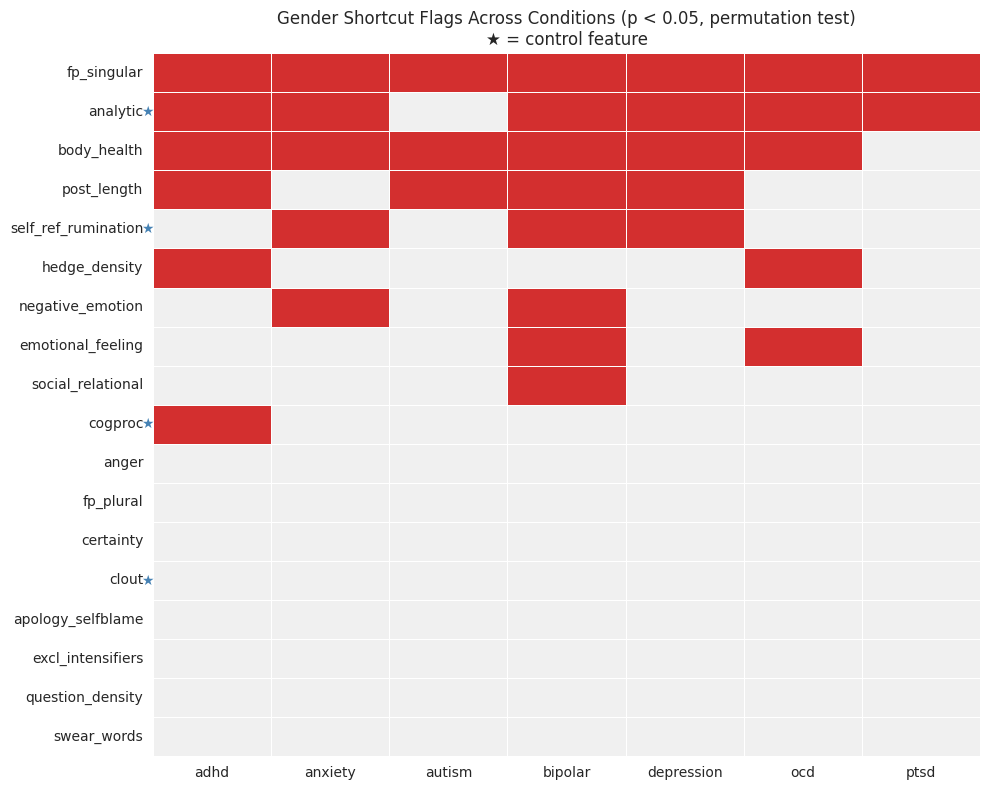


Shortcut in ALL 7 conditions: ['fp_singular']
Shortcut in NO conditions:  ['anger', 'fp_plural', 'certainty', 'clout', 'apology_selfblame', 'excl_intensifiers', 'question_density', 'swear_words']

Control feature behaviour:
  analytic: flagged in 6/7 conditions
  clout: flagged in 0/7 conditions
  cogproc: flagged in 1/7 conditions
  self_ref_rumination: flagged in 3/7 conditions


In [54]:
# ================================================================
# CROSS-CONDITION SUMMARY: which features are shortcuts everywhere?
# ================================================================

# Pivot: feature × condition → sig_005 (True/False)
pivot = cross_df.pivot_table(index='feature', columns='condition', values='sig_005', aggfunc='first')
pivot = pivot.fillna(False).astype(bool)

# Count how many conditions each feature is a significant shortcut in
pivot['n_conditions'] = pivot.sum(axis=1)
pivot = pivot.sort_values('n_conditions', ascending=False)

# Mark controls
CONTROL_FEATURES = {'cogproc', 'self_ref_rumination', 'analytic', 'clout'}
pivot['is_control'] = pivot.index.isin(CONTROL_FEATURES)

print("Feature × Condition shortcut matrix (p < 0.05 permutation test)")
print("=" * 70)
print(pivot.to_string())

# ── Heatmap ───────────────────────────────────────────────────────────────────
conditions = [c for c in pivot.columns if c not in ('n_conditions', 'is_control')]
plot_data = pivot[conditions].astype(int)

fig, ax = plt.subplots(figsize=(max(10, len(conditions)*1.2), 8))
sns.heatmap(plot_data, cmap=['#f0f0f0', '#d32f2f'], cbar=False,
            linewidths=0.5, linecolor='white', ax=ax,
            yticklabels=True, xticklabels=True)

# Highlight controls with a different marker
for i, feat in enumerate(plot_data.index):
    if feat in CONTROL_FEATURES:
        ax.annotate('★', xy=(0, i + 0.5), fontsize=10, ha='right', va='center', color='steelblue')

ax.set_title('Gender Shortcut Flags Across Conditions (p < 0.05, permutation test)\n★ = control feature')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
n_conds = len(conditions)
always_shortcut = pivot[pivot['n_conditions'] == n_conds].index.tolist()
never_shortcut  = pivot[pivot['n_conditions'] == 0].index.tolist()
print(f"\nShortcut in ALL {n_conds} conditions: {always_shortcut or 'none'}")
print(f"Shortcut in NO conditions:  {never_shortcut or 'none'}")
print(f"\nControl feature behaviour:")
for f in sorted(CONTROL_FEATURES):
    if f in pivot.index:
        n = pivot.loc[f, 'n_conditions']
        print(f"  {f}: flagged in {n}/{n_conds} conditions")